In [41]:
# ============================================================
# 1. IMPORTS
# ============================================================

import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
sns.set(style="whitegrid")

In [42]:
# ============================================================
# 2. DATA LOADING
# ============================================================

BASE_PATH = "/kaggle/input/datasets/nagasai524/anomaly-detection-in-helicopter/"

train_df = pd.read_csv(
    BASE_PATH + "train_df.csv",
    header=None,
    skiprows=1,
    index_col=0
)

validation_df = pd.read_csv(
    BASE_PATH + "validation_df.csv",
    header=None,
    skiprows=1,
    index_col=0
)

groundtruth_df = pd.read_csv(BASE_PATH + "dfvalid_groundtruth.csv")

X_train_raw = train_df.values.astype(np.float32)
X_test_raw = validation_df.values.astype(np.float32)
y_test = groundtruth_df["anomaly"].values.astype(int)

In [43]:
# ============================================================
# 3. TRAIN/VAL SPLIT (NORMAL ONLY)
# ============================================================

def train_val_split_normal(X, val_ratio=0.2):
    idx = np.random.permutation(len(X))
    split = int(len(X)*(1-val_ratio))
    return X[idx[:split]], X[idx[split:]]

X_train_split, X_val_split = train_val_split_normal(X_train_raw)

In [44]:
# ============================================================
# 4. GLOBAL SCALING (TRAIN ONLY)
# ============================================================

mean_train = X_train_split.mean()
std_train = X_train_split.std() + 1e-8

def scale(X):
    return (X - mean_train) / std_train

X_train_scaled = scale(X_train_split)
X_val_scaled   = scale(X_val_split)
X_test_scaled  = scale(X_test_raw)

In [45]:
# ============================================================
# 5. FEATURE ENGINEERING (STABLE)
# ============================================================

def compute_derivative(X):
    return np.diff(X, axis=1, prepend=X[:, :1])

def compute_fft(X):
    fft_vals = np.fft.rfft(X, axis=1)
    mag = np.abs(fft_vals)
    return np.log1p(mag)  # log compression (stability)

X_train_der = compute_derivative(X_train_scaled)
X_val_der   = compute_derivative(X_val_scaled)
X_test_der  = compute_derivative(X_test_scaled)

X_train_fft = compute_fft(X_train_scaled)
X_val_fft   = compute_fft(X_val_scaled)
X_test_fft  = compute_fft(X_test_scaled)

In [46]:
# ============================================================
# 6. DATALOADER
# ============================================================

def create_loader(X, X_der, X_fft, batch_size=64, shuffle=True):
    dataset = TensorDataset(
        torch.tensor(X).unsqueeze(1),
        torch.tensor(X_der).unsqueeze(1),
        torch.tensor(X_fft)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


# ============================================================
# 7. MODEL (STABLE INIT)
# ============================================================

class PMSRAN(nn.Module):
    def __init__(self, signal_len, fft_len, hidden=64):
        super().__init__()

        self.temporal = nn.Sequential(
            nn.Conv1d(1, hidden, 7, padding=3),
            nn.ReLU(),
            nn.Conv1d(hidden, hidden*2, 5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(32)
        )

        self.derivative = nn.Sequential(
            nn.Conv1d(1, hidden, 5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(32)
        )

        self.freq = nn.Sequential(
            nn.Linear(fft_len, 128),
            nn.ReLU(),
            nn.Linear(128, hidden),
            nn.ReLU()
        )

        fusion_dim = hidden*2*32 + hidden*32 + hidden
        self.fusion = nn.Linear(fusion_dim, 256)

        self.time_dec = nn.Linear(256, signal_len)
        self.der_dec  = nn.Linear(256, signal_len)
        self.freq_dec = nn.Linear(256, fft_len)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, x_der, x_fft):
        t = self.temporal(x).flatten(1)
        d = self.derivative(x_der).flatten(1)
        f = self.freq(x_fft)

        latent = self.fusion(torch.cat([t, d, f], dim=1))

        return (
            self.time_dec(latent),
            self.der_dec(latent),
            self.freq_dec(latent)
        )

In [47]:
# ============================================================
# 8. TRAINING (EARLY STOP + AMP + CLIP)
# ============================================================

def train_model(model, train_loader, val_loader, lr=5e-4, epochs=50, patience=7):

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_loss = np.inf
    best_weights = None
    patience_counter = 0

    train_losses, val_losses = [],[]
    start_time = time.time()

    for epoch in range(epochs):

        model.train()
        total_train = 0

        for x, x_der, x_fft in train_loader:
            x, x_der, x_fft = x.to(device), x_der.to(device), x_fft.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                t_rec, d_rec, f_rec = model(x, x_der, x_fft)
                loss = (
                    criterion(t_rec, x.squeeze(1)) +
                    criterion(d_rec, x_der.squeeze(1)) +
                    criterion(f_rec, x_fft)
                )

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            total_train += loss.item()

        train_loss = total_train / len(train_loader)

        model.eval()
        total_val = 0

        with torch.no_grad():
            for x, x_der, x_fft in val_loader:
                x, x_der, x_fft = x.to(device), x_der.to(device), x_fft.to(device)
                t_rec, d_rec, f_rec = model(x, x_der, x_fft)

                loss = (
                    criterion(t_rec, x.squeeze(1)) +
                    criterion(d_rec, x_der.squeeze(1)) +
                    criterion(f_rec, x_fft)
                )

                total_val += loss.item()

        val_loss = total_val / len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1} | Train {train_loss:.6f} | Val {val_loss:.6f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    training_time = time.time() - start_time
    model.load_state_dict(best_weights)

    return model, train_losses, val_losses, training_time

In [48]:
# ============================================================
# 9. SCORING
# ============================================================

def compute_scores(model, loader):
    model.eval()
    scores = []
    originals = []
    recons = []

    start = time.time()

    with torch.no_grad():
        for x, x_der, x_fft in loader:
            x, x_der, x_fft = x.to(device), x_der.to(device), x_fft.to(device)
            t_rec, d_rec, f_rec = model(x, x_der, x_fft)

            time_err = ((t_rec - x.squeeze(1))**2).mean(dim=1)
            der_err  = ((d_rec - x_der.squeeze(1))**2).mean(dim=1)
            freq_err = ((f_rec - x_fft)**2).mean(dim=1)

            score = time_err + der_err + freq_err

            scores.extend(score.cpu().numpy())
            originals.extend(x.squeeze(1).cpu().numpy())
            recons.extend(t_rec.cpu().numpy())

    inference_time = time.time() - start

    return np.array(scores), np.array(originals), np.array(recons), inference_time

In [49]:
# ============================================================
# 10. TRAIN
# ============================================================

model = PMSRAN(
    signal_len=X_train_scaled.shape[1],
    fft_len=X_train_fft.shape[1],
    hidden=64
).to(device)

train_loader = create_loader(X_train_scaled, X_train_der, X_train_fft)
val_loader   = create_loader(X_val_scaled, X_val_der, X_val_fft, shuffle=False)
test_loader  = create_loader(X_test_scaled, X_test_der, X_test_fft, shuffle=False)

model, train_losses, val_losses, train_time = train_model(
    model, train_loader, val_loader
)

/tmp/ipykernel_149/902777442.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_149/902777442.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 1 | Train 7.114353 | Val 2.257692
Epoch 2 | Train 2.320367 | Val 1.973505
Epoch 3 | Train 2.234141 | Val 1.968065
Epoch 4 | Train 2.232460 | Val 1.956275
Epoch 5 | Train 2.225760 | Val 1.957647
Epoch 6 | Train 2.222557 | Val 1.935125
Epoch 7 | Train 2.194927 | Val 1.905174
Epoch 8 | Train 2.156676 | Val 1.866494
Epoch 9 | Train 2.123853 | Val 1.843932
Epoch 10 | Train 2.108991 | Val 1.834817
Epoch 11 | Train 2.100294 | Val 1.834418
Epoch 12 | Train 2.100921 | Val 1.835243
Epoch 13 | Train 2.096298 | Val 1.833041
Epoch 14 | Train 2.097043 | Val 1.832548
Epoch 15 | Train 2.094847 | Val 1.832724
Epoch 16 | Train 2.093661 | Val 1.830962
Epoch 17 | Train 2.089644 | Val 1.829830
Epoch 18 | Train 2.086679 | Val 1.824090
Epoch 19 | Train 2.079009 | Val 1.820289
Epoch 20 | Train 2.070364 | Val 1.812261
Epoch 21 | Train 2.057289 | Val 1.807173
Epoch 22 | Train 2.046519 | Val 1.803361
Epoch 23 | Train 2.041183 | Val 1.801803
Epoch 24 | Train 2.034954 | Val 1.801057
Epoch 25 | Train 2.036648

In [50]:
# ============================================================
# 11. EVALUATION
# ============================================================

scores_test, originals_test, recon_test, infer_time = compute_scores(model, test_loader)

fpr, tpr, thresholds = roc_curve(y_test, scores_test)
auc_score = roc_auc_score(y_test, scores_test)

youden = np.argmax(tpr - fpr)
threshold = thresholds[youden]
y_pred = (scores_test >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("AUC:", auc_score)
print("F1:", f1)
print("Precision:", precision)
print("Recall:", recall)
print("Training Time:", train_time)
print("Inference Time:", infer_time)
print("Confusion Matrix:\n", cm)

AUC: 0.86503644752803
F1: 0.8530465949820788
Precision: 0.9118773946360154
Recall: 0.8013468013468014
Training Time: 697.7015442848206
Inference Time: 2.5646262168884277
Confusion Matrix:
 [[274  23]
 [ 59 238]]


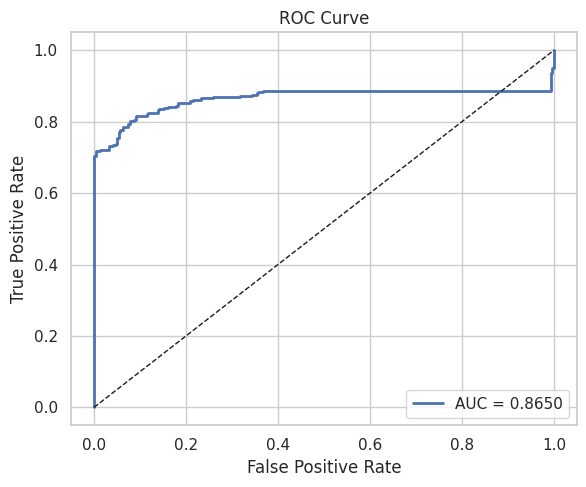

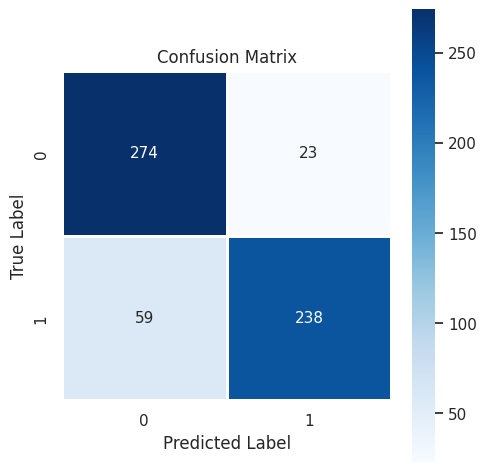

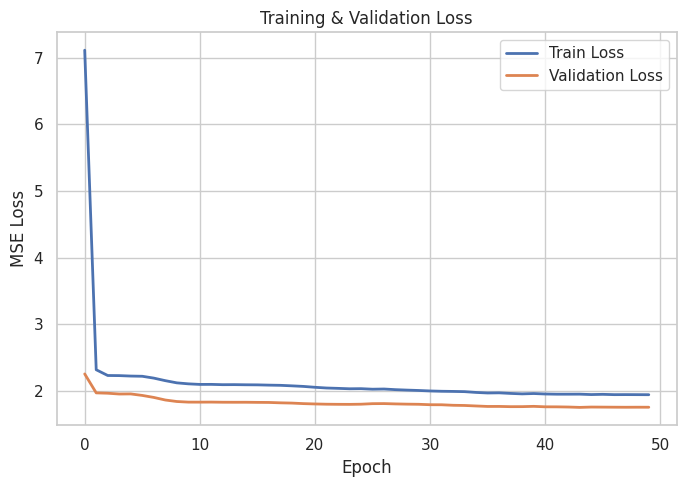

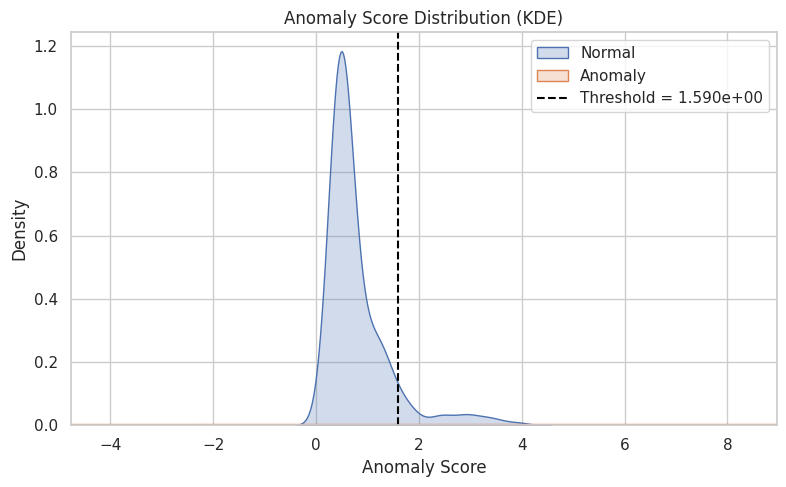

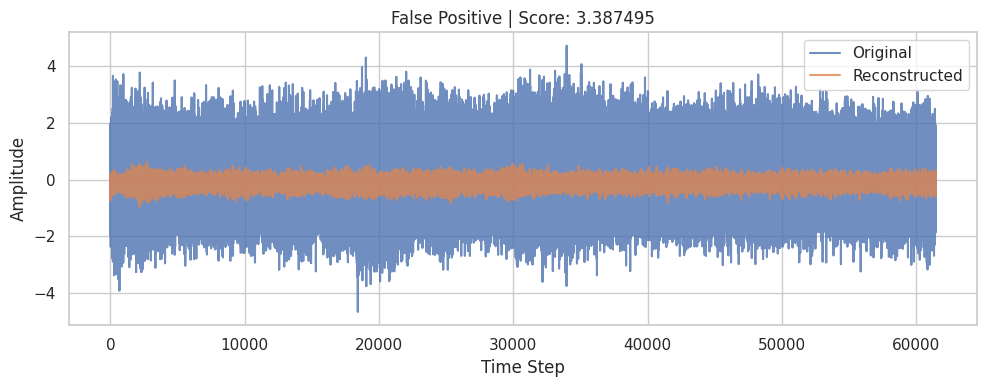

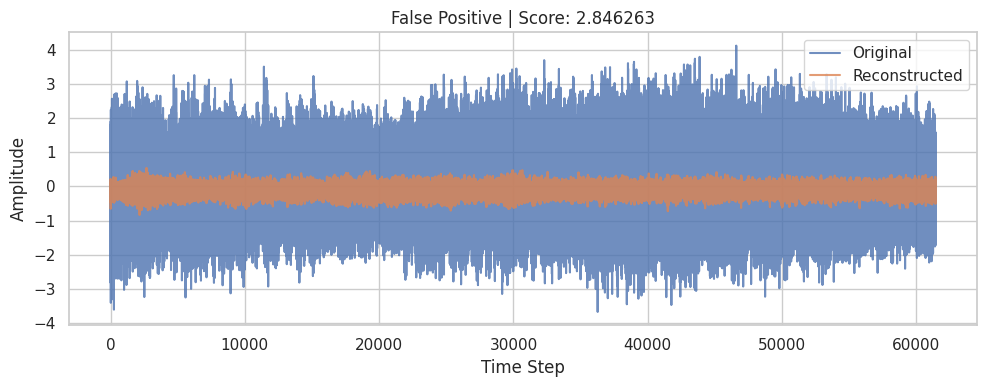

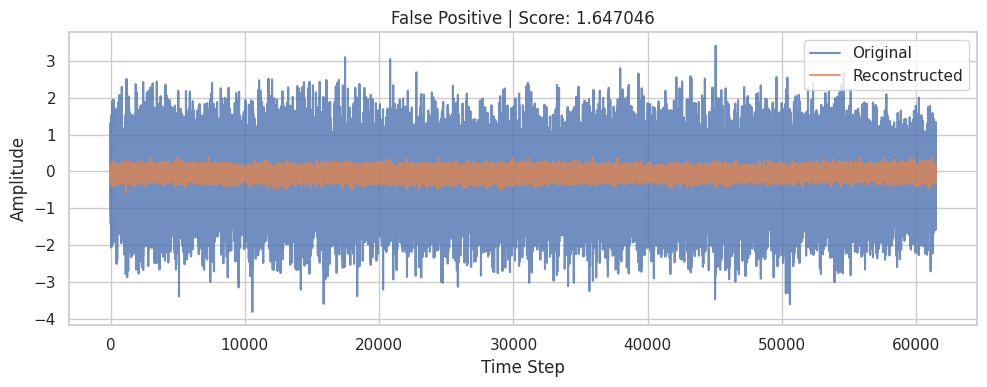

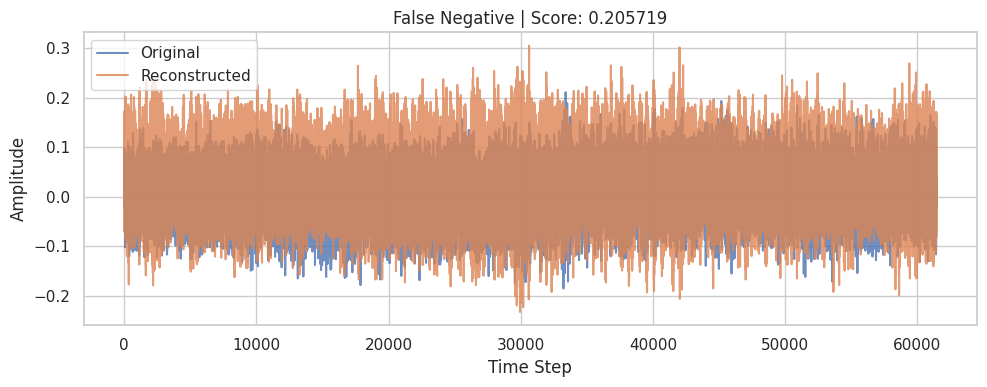

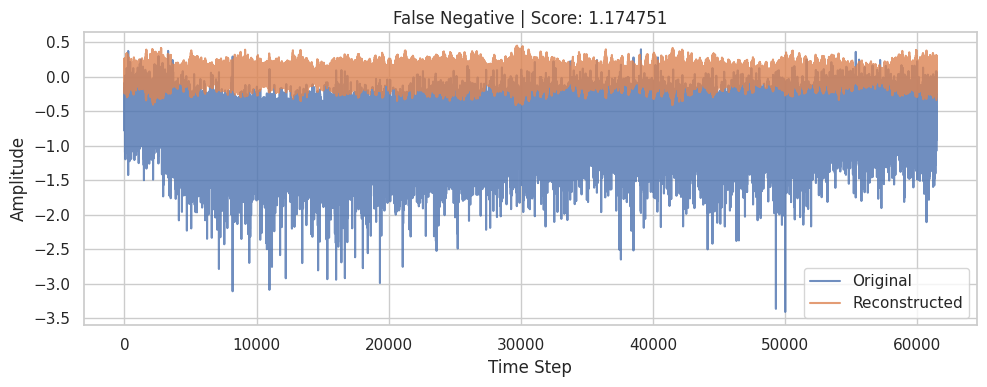

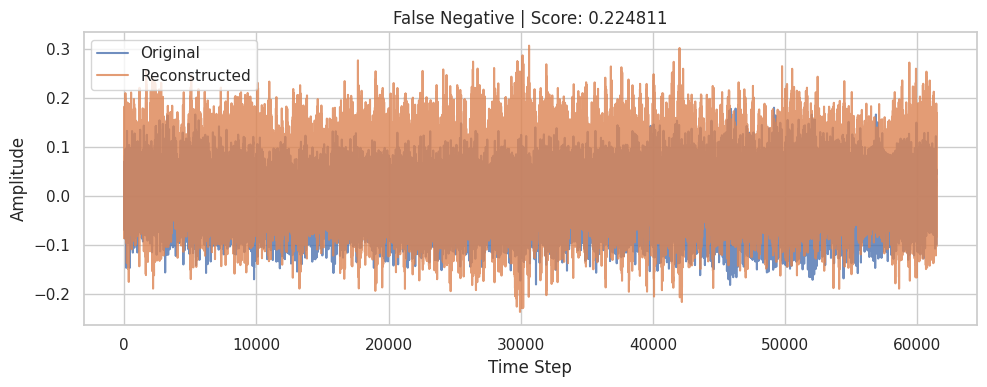

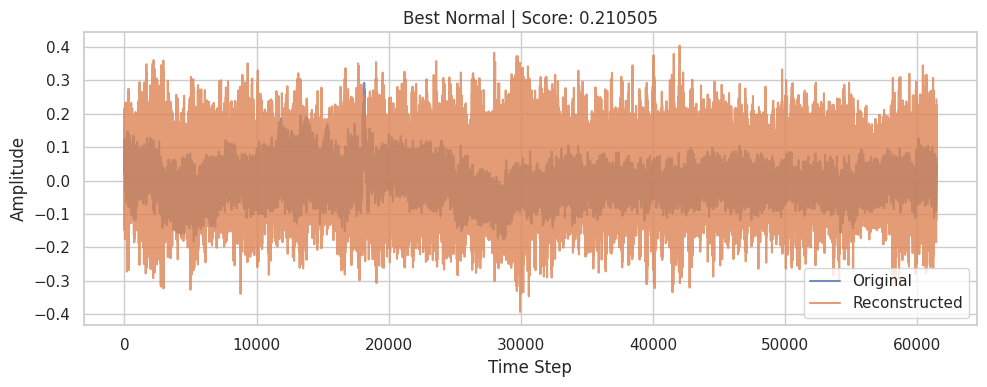

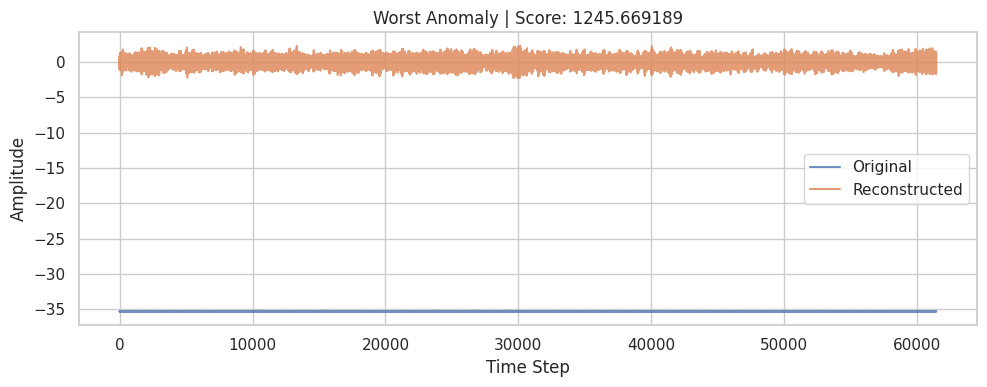

In [51]:
# ============================================================
# 12. PROFESSIONAL VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc
import numpy as np

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 11})

# ------------------------------------------------------------
# ROC CURVE (with AUC)
# ------------------------------------------------------------
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# CONFUSION MATRIX (square, white→dark blue)
# ------------------------------------------------------------
plt.figure(figsize=(5,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=1,
    linecolor="white"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# TRAINING / VALIDATION LOSS
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(train_losses, linewidth=2, label="Train Loss")
plt.plot(val_losses, linewidth=2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SCORE DISTRIBUTION
# ------------------------------------------------------------
plt.figure(figsize=(8,5))

all_scores = np.concatenate([normal_scores, anomaly_scores])

sns.kdeplot(normal_scores, fill=True, label="Normal")
sns.kdeplot(anomaly_scores, fill=True, label="Anomaly")

plt.axvline(threshold, color="black", linestyle="--",
            label=f"Threshold = {threshold:.3e}")

plt.xlim(normal_scores.min()-5, normal_scores.max()+5)
plt.xlabel("Anomaly Score")
plt.title("Anomaly Score Distribution (KDE)")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SIGNAL PLOTTING FUNCTION
# ------------------------------------------------------------
def plot_signal(idx, title):
    score = scores_test[idx]
    
    plt.figure(figsize=(10,4))
    plt.plot(originals_test[idx], 
             linewidth=1.5, 
             alpha=0.8, 
             label="Original")
    
    plt.plot(recon_test[idx], 
             linewidth=1.5, 
             alpha=0.8, 
             label="Reconstructed")
    
    plt.title(f"{title} | Score: {score:.6f}")
    plt.xlabel("Time Step")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# MISCLASSIFIED SIGNALS
# ------------------------------------------------------------
fp = np.where((y_test==0) & (y_pred==1))[0]
fn = np.where((y_test==1) & (y_pred==0))[0]

for i in fp[:3]:
    plot_signal(i, "False Positive")

for i in fn[:3]:
    plot_signal(i, "False Negative")


# ------------------------------------------------------------
# EXTREME SIGNALS
# ------------------------------------------------------------
best_normal = np.where(y_test==0)[0][np.argmin(scores_test[y_test==0])]
worst_anomaly = np.where(y_test==1)[0][np.argmax(scores_test[y_test==1])]

plot_signal(best_normal, "Best Normal")
plot_signal(worst_anomaly, "Worst Anomaly")